### Plotting for the paper

In [1]:
import ast
import gzip
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

delta_df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_OT_1_rc.csv")

predictions = pd.read_csv(
    "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/gosai/k562_gosai_ref_alt_with_seq.csv.gz",
    compression="gzip"
)

predictions["offset_0"] = predictions["offset_0"].apply(ast.literal_eval)

predictions["ref"] = predictions["offset_0"].apply(lambda x: x["ref"])
predictions["alt"] = predictions["offset_0"].apply(lambda x: x["alt"])

predictions["variant_effect"] = predictions["ref"] - predictions["alt"]
predictions["ref_seq"] = predictions["offset_0"].apply(lambda x: x["ref_seq"])
predictions["alt_seq"] = predictions["offset_0"].apply(lambda x: x["alt_seq"])

filtered_variants = predictions[
    (predictions["variant_effect"] > 0.5) | (predictions["variant_effect"] < -0.5)
]

print(filtered_variants.shape)
print(delta_df.shape)

(2956, 6)
(2956, 13)


In [2]:
import ast 

delta_df["ism"] = delta_df["ism"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=float)
)

filtered_variants["variant_effect"] = filtered_variants["variant_effect"].astype(float)

delta_df["ism_scaled"] = [
    ism / ve if ve != 0 else np.zeros_like(ism)
    for ism, ve in zip(delta_df["ism"], filtered_variants["variant_effect"])
]

print(delta_df["ism_scaled"].head(5))

0    [0.012130224179491758, 0.01248827494646467, -0...
1    [0.02331111809410077, -0.05131290664048528, -0...
2    [-0.0034723781662645407, 2.06234378289384e-05,...
3    [-0.007012580129761172, -0.014264399153087845,...
4    [-0.013192904790065336, -0.008835330028309132,...
Name: ism_scaled, dtype: object


/tmp/ipykernel_2950717/298968781.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_variants["variant_effect"] = filtered_variants["variant_effect"].astype(float)


### First plot a high vs low

In [3]:
# Compute average ISM per sequence
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import ast

# --- Average numeric entries from dicts ---
def avg_numeric_dicts(dict_list):
    vals = []
    for d in dict_list:
        nums = [v for k, v in d.items() if isinstance(v, (int, float))]
        vals.append(np.mean(nums) if nums else np.nan)
    return np.array(vals)

# Apply across all rows
delta_df["ism_predictions_ref"] = delta_df["ism_predictions_ref"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=dict)
)
# Apply across all rows
delta_df["ism_predictions_alt"] = delta_df["ism_predictions_alt"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=dict)
)

ism_alt_avg = delta_df["ism_predictions_alt"].apply(avg_numeric_dicts)
ism_ref_avg = delta_df["ism_predictions_ref"].apply(avg_numeric_dicts)

# Variant effect
variant_effect = filtered_variants["variant_effect"].values

# Initialize lists
high_rows = []
low_rows = []

for i, effect in enumerate(variant_effect):
    if effect > 0:
        # high effect → take ref ISM
        high_rows.append(ism_ref_avg.iloc[i])
        # low effect → take alt ISM
        low_rows.append(ism_alt_avg.iloc[i])
    else:
        # effect < 0 → flip
        high_rows.append(ism_alt_avg.iloc[i])
        low_rows.append(ism_ref_avg.iloc[i])

# Convert to arrays for heatmaps
high_array = np.vstack(high_rows)
low_array  = np.vstack(low_rows)


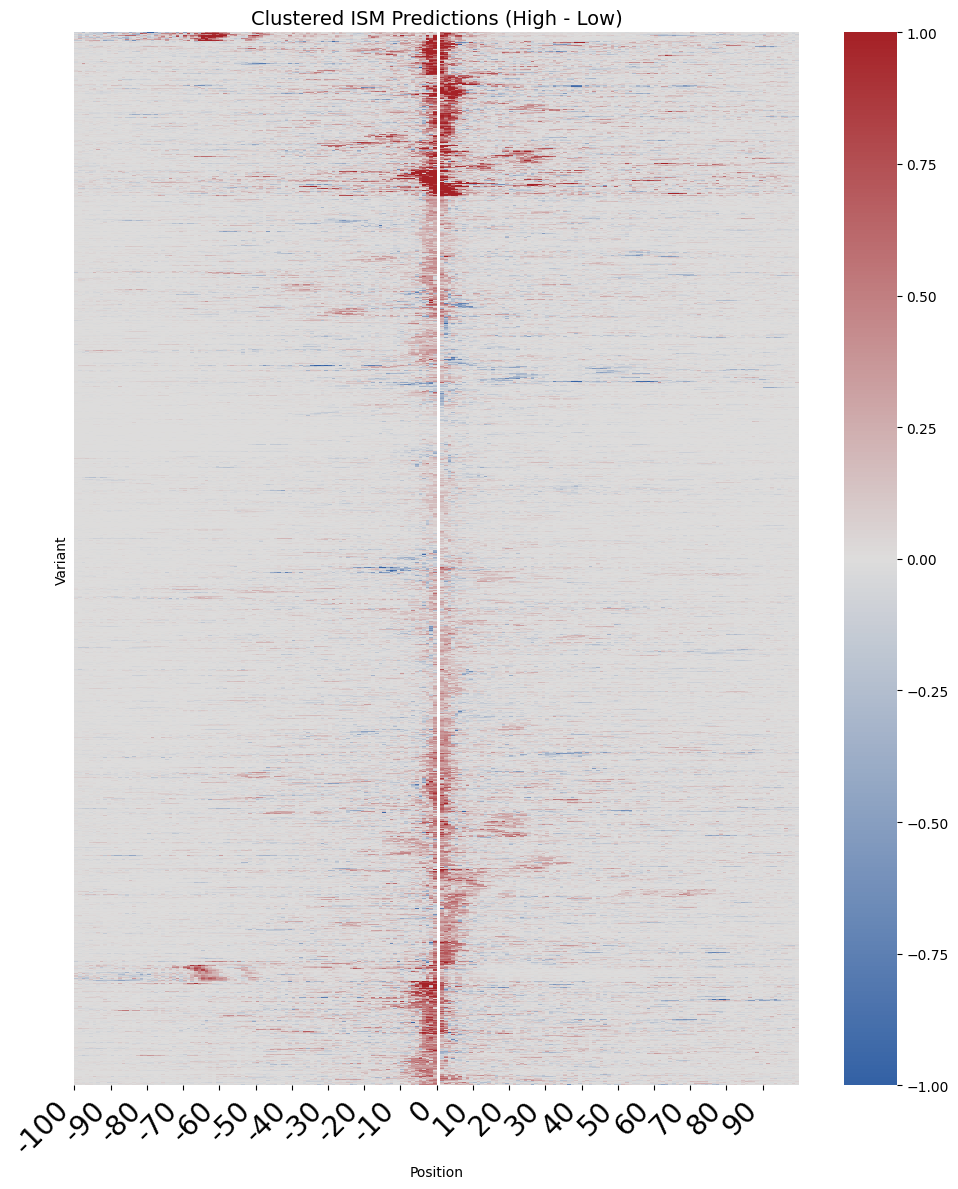

In [4]:
diff_array = high_array - low_array

from scipy.cluster.hierarchy import linkage, leaves_list

row_labels = delta_df.index.astype(str).tolist()
row_linkage = linkage(diff_array, method='ward', metric='euclidean')
row_order = leaves_list(row_linkage)

# Reorder diff_array and row labels according to clustering
heatmap_array = diff_array[row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1
# vmin = np.min(diff_array)
# vmax = np.max(diff_array)

coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (High - Low)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
tick_positions = np.arange(0, 200, 10)
tick_labels    = np.arange(-100, 100, 10)

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=20)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism.png", dpi=1200)
plt.show()


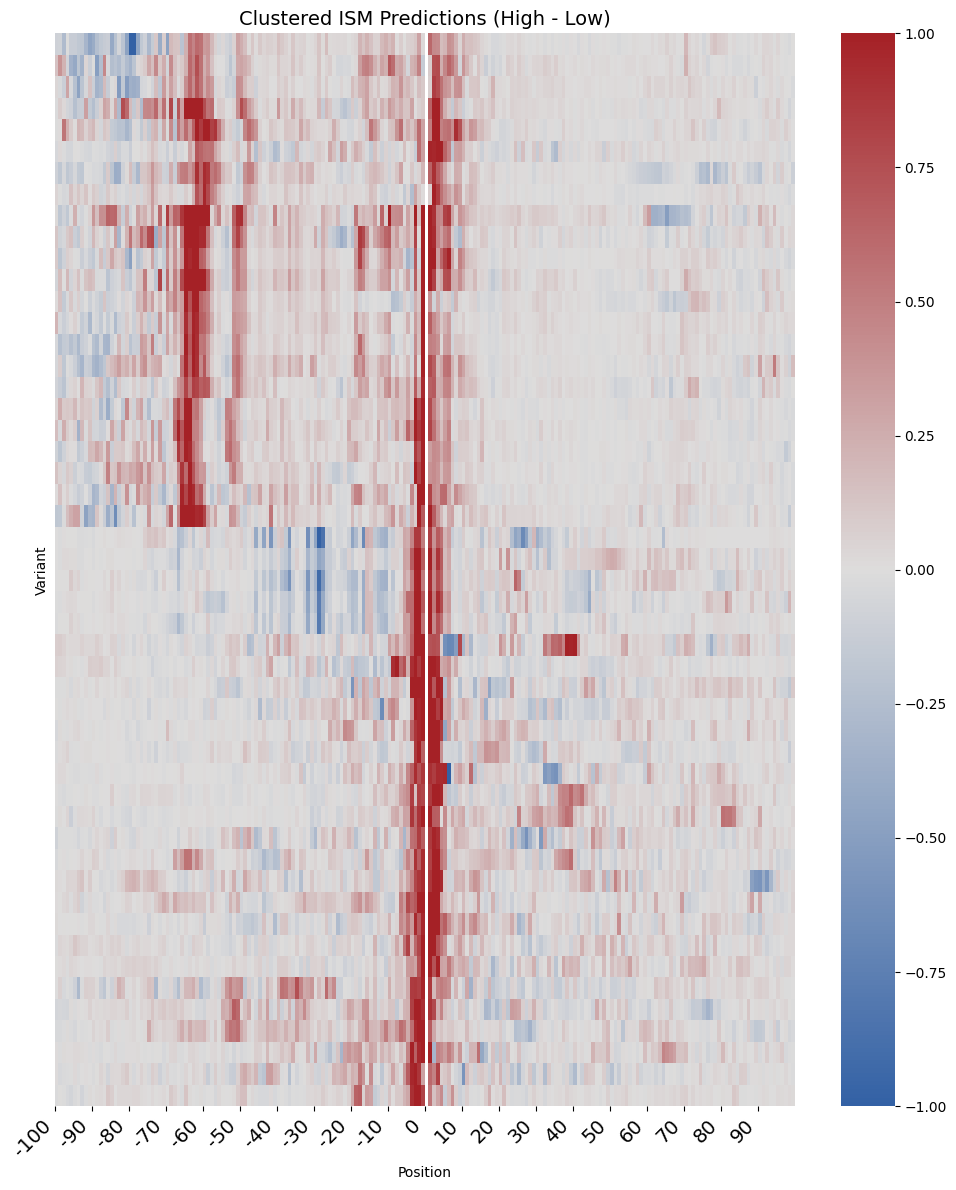

In [5]:
### Only plotting 2630 to 2643 for revcomp and forward

# diff_array = high_array - low_array
# diff_array = diff_array[0:50]
from scipy.cluster.hierarchy import linkage, leaves_list

# Reorder diff_array and row labels according to clustering
heatmap_array = heatmap_array[0:50]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1


coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (High - Low)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
tick_positions = np.arange(0, 200, 10)
tick_labels    = np.arange(-100, 100, 10)

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=14)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_group1.png", dpi=1200)
plt.show()



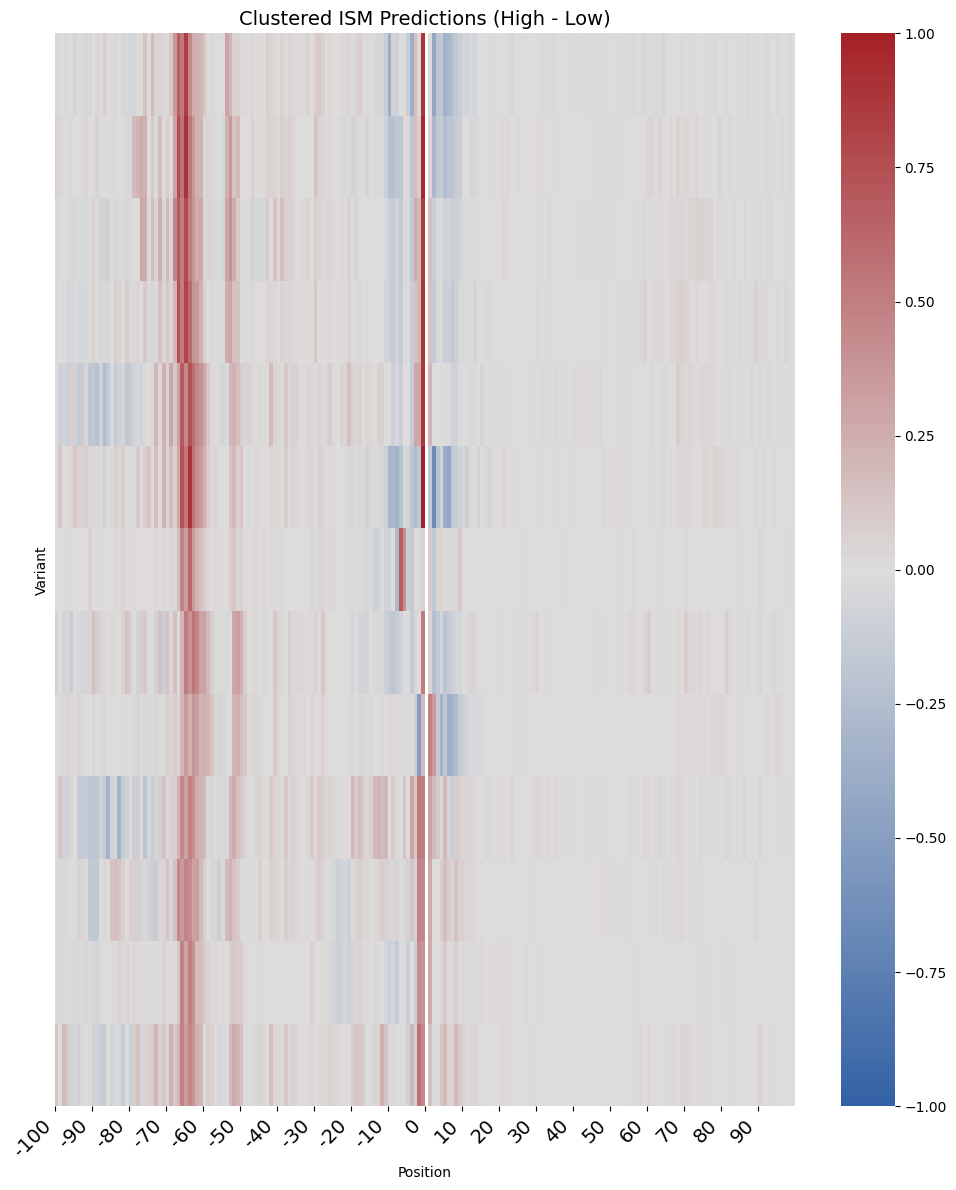

In [6]:
### Only plotting 2630 to 2643 for revcomp and forward

diff_array = high_array - low_array

from scipy.cluster.hierarchy import linkage, leaves_list

row_labels = delta_df.index.astype(str).tolist()
row_linkage = linkage(diff_array, method='ward', metric='euclidean')
row_order = leaves_list(row_linkage)

# Reorder diff_array and row labels according to clustering
heatmap_array = diff_array[row_order]
from scipy.cluster.hierarchy import linkage, leaves_list

# Reorder diff_array and row labels according to clustering
heatmap_array = heatmap_array[2630:2643]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1


coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (High - Low)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
tick_positions = np.arange(0, 200, 10)
tick_labels    = np.arange(-100, 100, 10)

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=14)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_group2.png", dpi=1200)
plt.show()



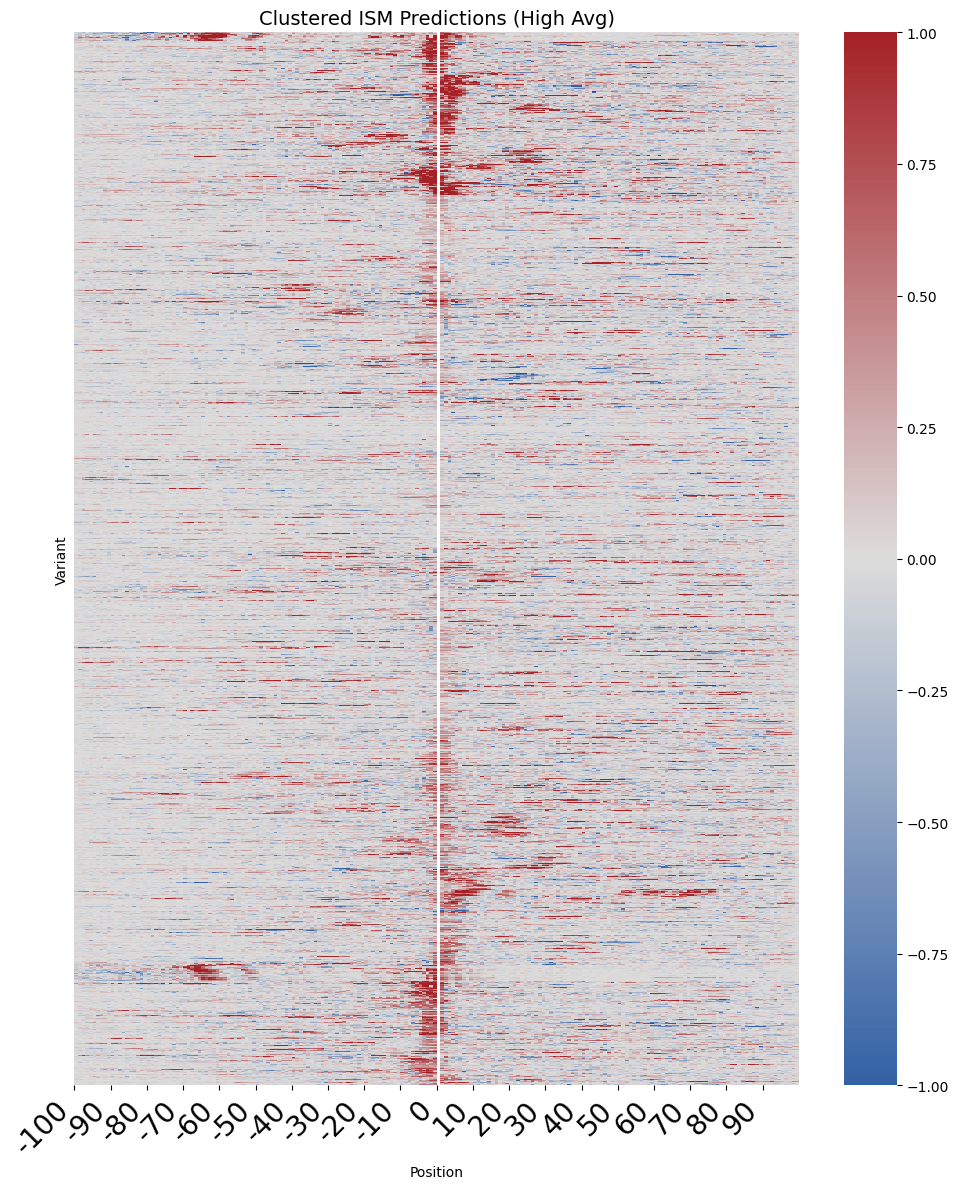

In [7]:
heatmap_array = high_array[row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1

coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (High Avg)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=20)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_high.png", dpi=1200)

plt.show()


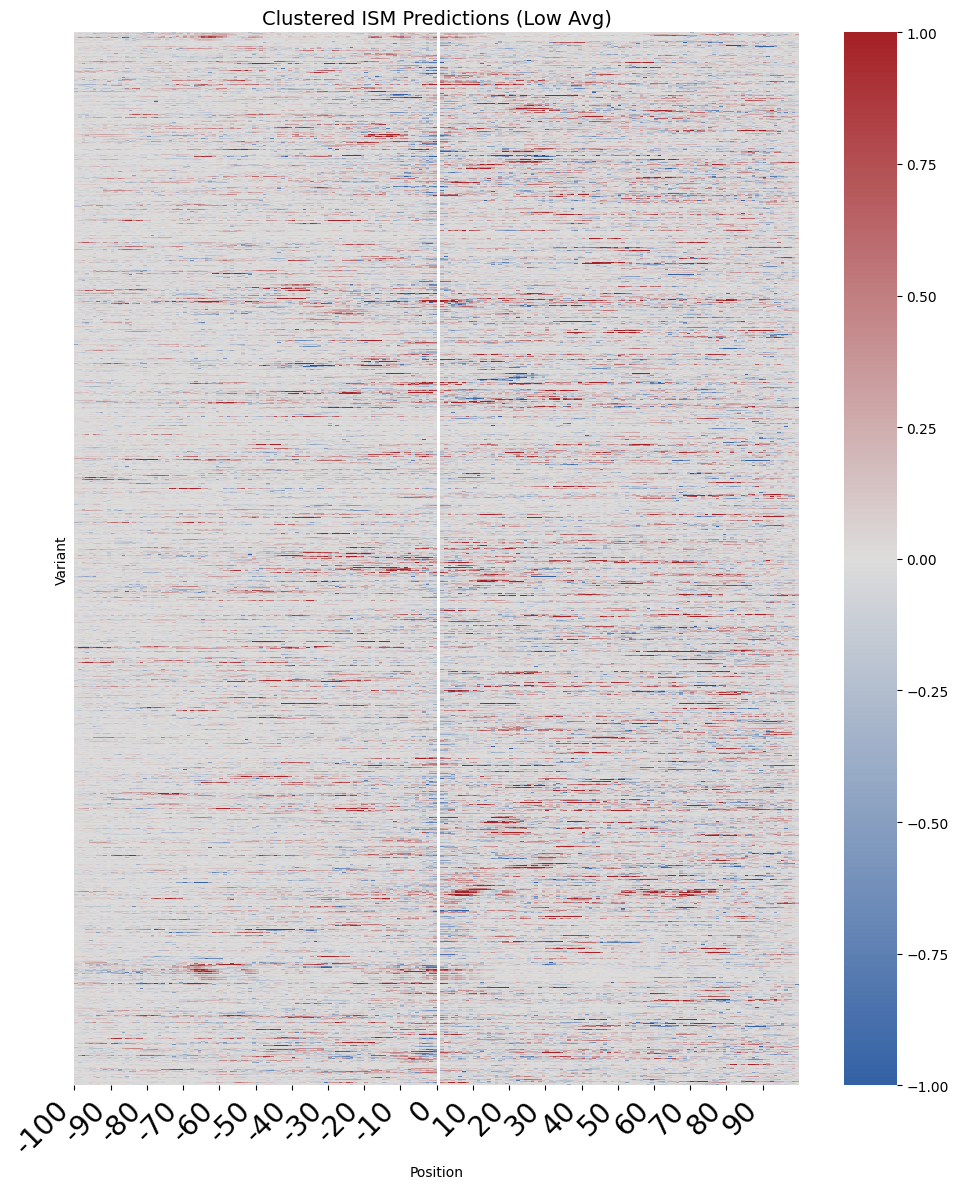

In [8]:
heatmap_array = low_array[row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1

coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (Low Avg)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=20)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_low.png", dpi=1200)

plt.show()


### Now we plot an average of the h1-h2. The goal here is to see if there are peaks at certain positions

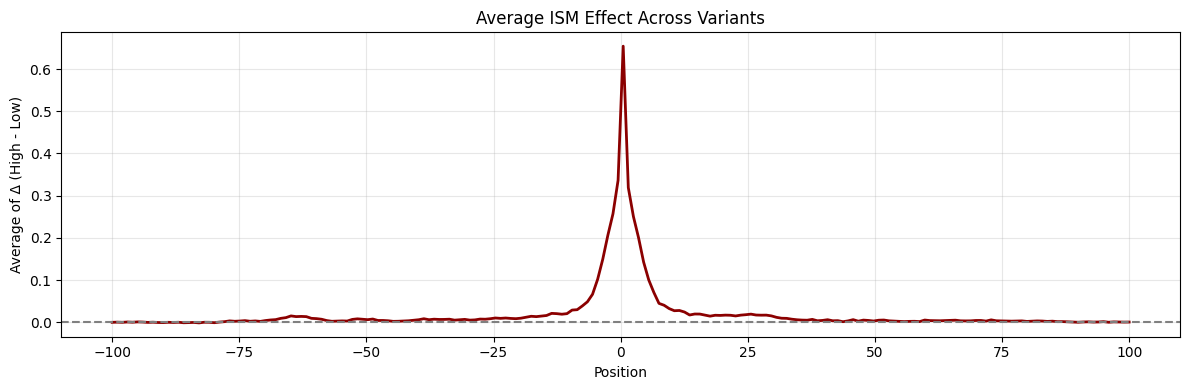

In [9]:
# --- Compute row-wise average and plot line graph ---
avg_diff = np.mean(diff_array, axis=0)  # average across rows
positions = np.linspace(-100, 100, diff_array.shape[1])

plt.figure(figsize=(12, 4))
plt.plot(positions, avg_diff, color='darkred', lw=2)
plt.axhline(0, color='grey', linestyle='--')
plt.xlabel("Position")
plt.ylabel("Average of Δ (High - Low)")
plt.title("Average ISM Effect Across Variants")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

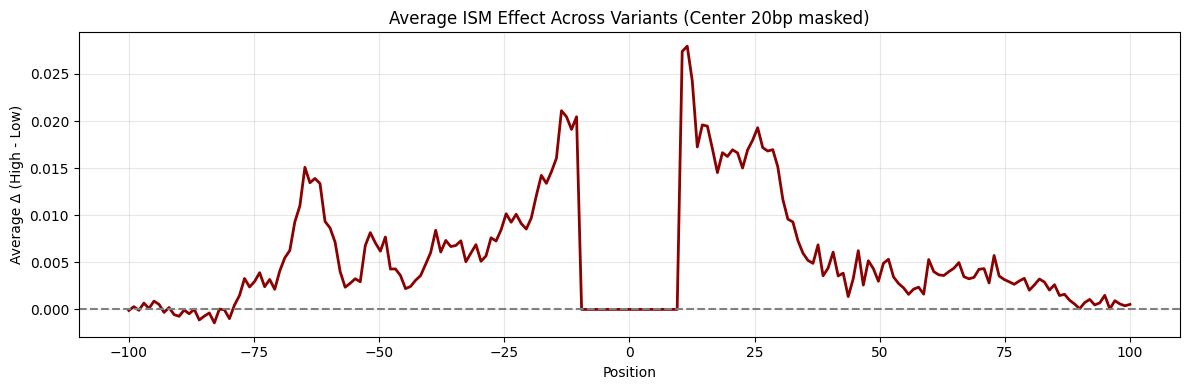

In [10]:
# --- Zero out positions -10 to 10 ---
num_cols = diff_array.shape[1]
positions = np.linspace(-100, 100, num_cols)

# Find the indices corresponding to -10 to 10
center_mask = (positions >= -10) & (positions <= 10)
diff_array[:, center_mask] = 0

# --- Compute row-wise average after masking center ---
avg_diff = np.mean(diff_array, axis=0)

# --- Plot line graph ---
plt.figure(figsize=(12, 4))
plt.plot(positions, avg_diff, color='darkred', lw=2)
plt.axhline(0, color='grey', linestyle='--')
plt.xlabel("Position")
plt.ylabel("Average Δ (High - Low)")
plt.title("Average ISM Effect Across Variants (Center 20bp masked)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


### Plot a few of the ISM

/tmp/ipykernel_2950717/729034315.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(x + 0)) for x in xticks])


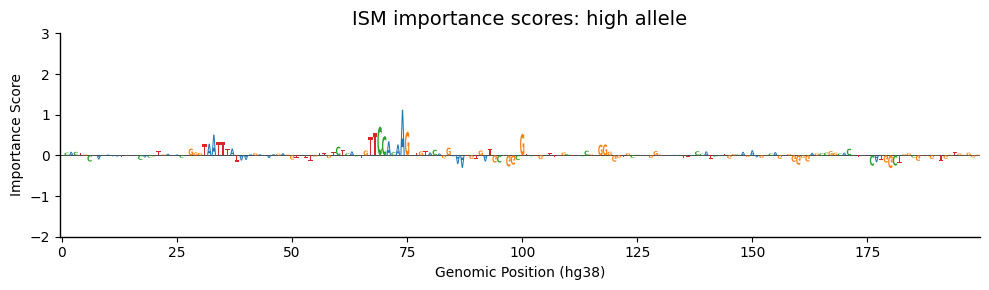

In [11]:
# Plot logo
import os
import logomaker

#### Plot for a single sequence ####
def plot_ism_logo_single(seq, scores, seq_id, save_path=None):
    color_scheme = {
        'A': '#1f77b4',
        'C': '#2ca02c',
        'G': '#ff7f0e',
        'T': '#d62728',
    }

    trimmed_seq = seq
    trimmed_scores = scores

    df = pd.DataFrame(0.0, index=range(len(trimmed_seq)), columns=["A", "C", "G", "T"])
    for i, base in enumerate(trimmed_seq):
        df.at[i, base] = trimmed_scores[i]

    fig, ax = plt.subplots(figsize=(10, 3))

    logo = logomaker.Logo(df, ax=ax, color_scheme=color_scheme)
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)

    ax.set_title(f"ISM importance scores: {seq_id}", fontsize=14)
    ax.set_xlabel("Genomic Position (hg38)")
    ax.set_ylabel("Importance Score")
    ax.set_ylim(-2, 3)

    # Genomic coordinate offset
    xticks = ax.get_xticks()
    ax.set_xticklabels([str(int(x + 0)) for x in xticks])

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, format="svg")

    plt.show()

filtered_variants_reordered = filtered_variants.iloc[row_order]

sequence = filtered_variants.iloc[2680]["ref_seq"]

heatmap_array = high_array[row_order]
ism_scores = heatmap_array[2680]
seq_id = "high allele"
outdir = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/OT_ism"
plot_ism_logo_single(sequence, ism_scores, seq_id,
                     save_path=f"{outdir}/{seq_id}_ISM_logo.svg")

/tmp/ipykernel_2950717/3415807947.py:34: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([str(int(x + 0)) for x in xticks])


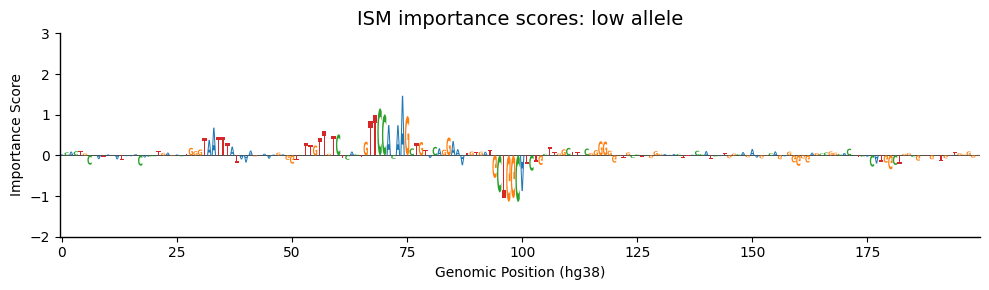

In [12]:
# Plot logo
import os
import logomaker

#### Plot for a single sequence ####
def plot_ism_logo_single(seq, scores, seq_id, save_path=None):
    color_scheme = {
        'A': '#1f77b4',
        'C': '#2ca02c',
        'G': '#ff7f0e',
        'T': '#d62728',
    }

    trimmed_seq = seq
    trimmed_scores = scores

    df = pd.DataFrame(0.0, index=range(len(trimmed_seq)), columns=["A", "C", "G", "T"])
    for i, base in enumerate(trimmed_seq):
        df.at[i, base] = trimmed_scores[i]

    fig, ax = plt.subplots(figsize=(10, 3))

    logo = logomaker.Logo(df, ax=ax, color_scheme=color_scheme)
    logo.style_spines(visible=False)
    logo.style_spines(spines=['left', 'bottom'], visible=True)

    ax.set_title(f"ISM importance scores: {seq_id}", fontsize=14)
    ax.set_xlabel("Genomic Position (hg38)")
    ax.set_ylabel("Importance Score")
    ax.set_ylim(-2, 3)

    # Genomic coordinate offset
    xticks = ax.get_xticks()
    ax.set_xticklabels([str(int(x + 0)) for x in xticks])

    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, format="svg")

    plt.show()

filtered_variants_reordered = filtered_variants.iloc[row_order]

sequence = filtered_variants.iloc[2680]["alt_seq"]

heatmap_array = low_array[row_order]
ism_scores = heatmap_array[2680]
seq_id = "low allele"
outdir = "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/OT_ism"
plot_ism_logo_single(sequence, ism_scores, seq_id,
                     save_path=f"{outdir}/{seq_id}_ISM_logo.svg")

### See if theres any relation among the first 10 rows

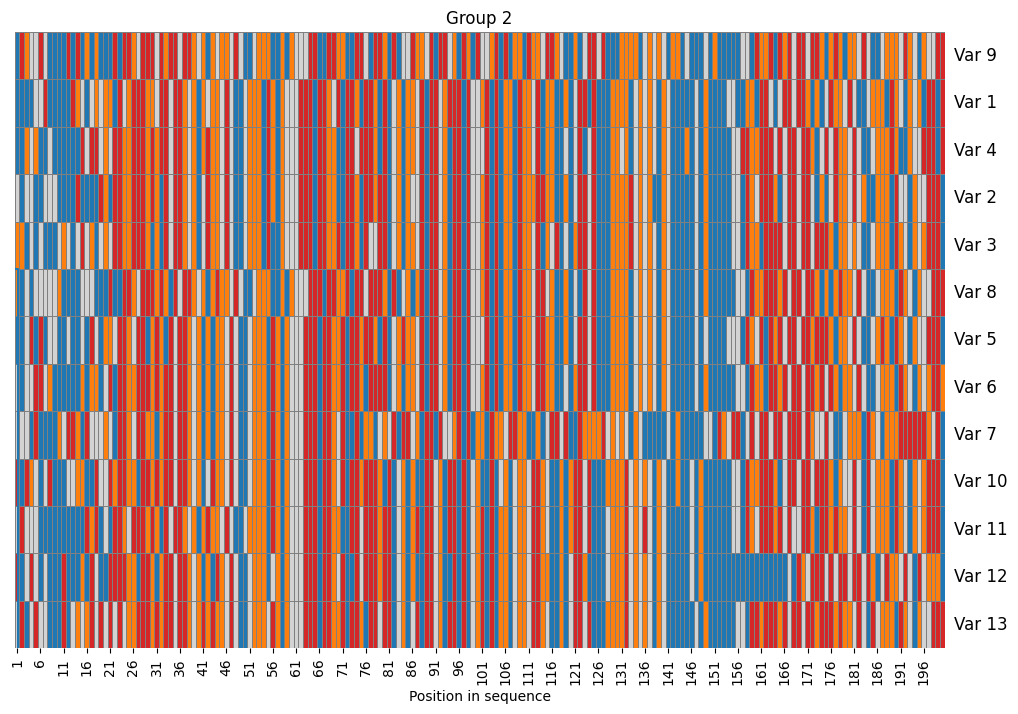

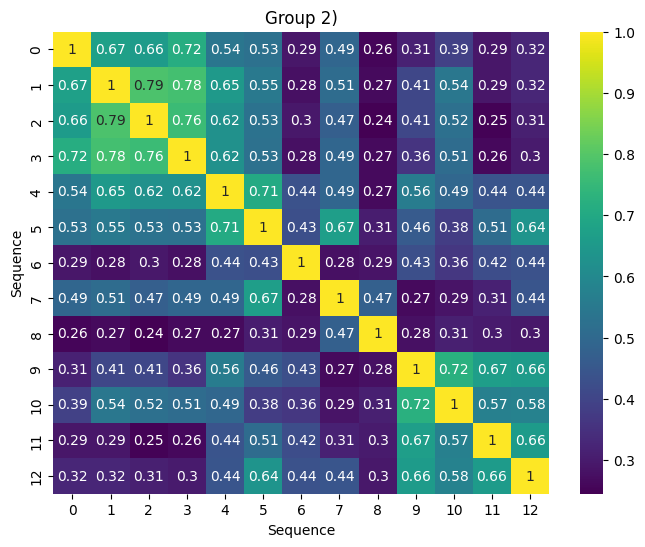

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram

# Take the first 15 sequences
seqs = filtered_variants_reordered["ref_seq"].iloc[2630:2643].tolist()

# Convert sequences to numeric (A=0, C=1, G=2, T=3, N=4)
nt_to_int = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
seq_array = np.array([[nt_to_int.get(nt, 4) for nt in seq] for seq in seqs])

# Compute pairwise Hamming distance (number of differences)
dist_matrix = pdist(seq_array, metric='hamming')

# Perform hierarchical clustering
linkage_matrix = linkage(dist_matrix, method='average')

# Plot dendrogram with heatmap
plt.figure(figsize=(12, 8))
dendro = dendrogram(linkage_matrix, labels=[f"Var {i+1}" for i in range(len(seqs))], orientation='left')

# Reorder seq_array according to clustering
seq_array_ordered = seq_array[dendro['leaves'], :]

# Define nucleotide color palette
cmap = sns.color_palette(["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#d3d3d3"])  # A, C, G, T, N

# Plot heatmap of sequences
sns.heatmap(seq_array_ordered, cmap=cmap, cbar=False, linewidths=0.5, linecolor='grey')
plt.yticks(np.arange(0.5, len(seqs)+0.5), [f"Var {i+1}" for i in dendro['leaves']], rotation=0)
plt.xticks(np.arange(0.5, seq_array.shape[1]+0.5, 5), np.arange(1, seq_array.shape[1]+1, 5))
plt.xlabel("Position in sequence")
plt.title("Group 2")
plt.show()

from scipy.spatial.distance import pdist, squareform

# Compute pairwise similarity (1 - Hamming distance)
dist_matrix = pdist(seq_array, metric='hamming')
sim_matrix = 1 - squareform(dist_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(sim_matrix, cmap="viridis", annot=True)
plt.title("Group 2)")
plt.xlabel("Sequence")
plt.ylabel("Sequence")
plt.show()



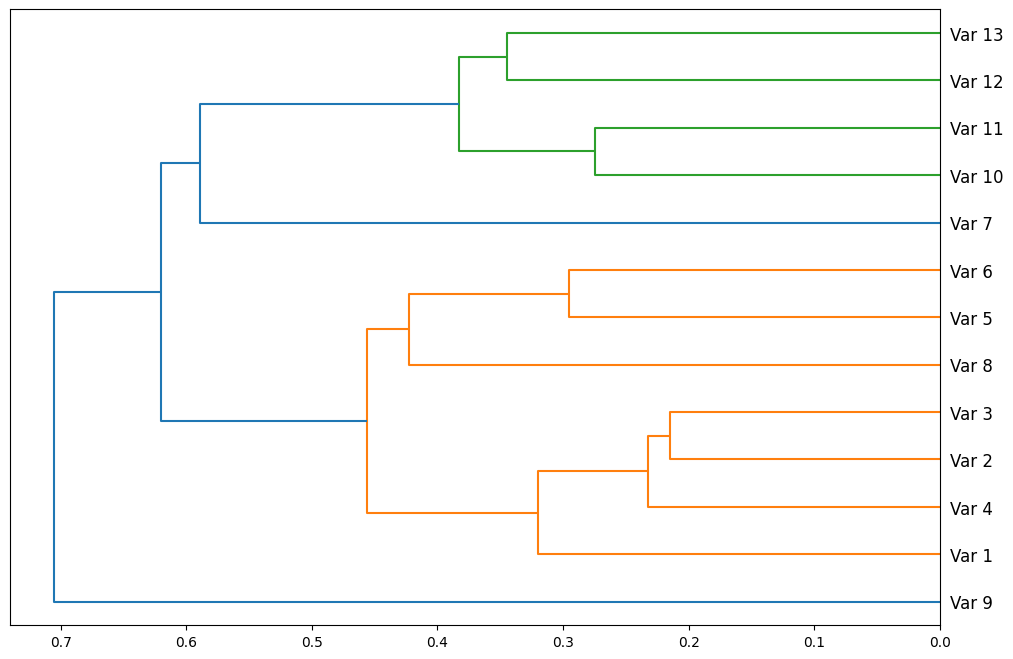

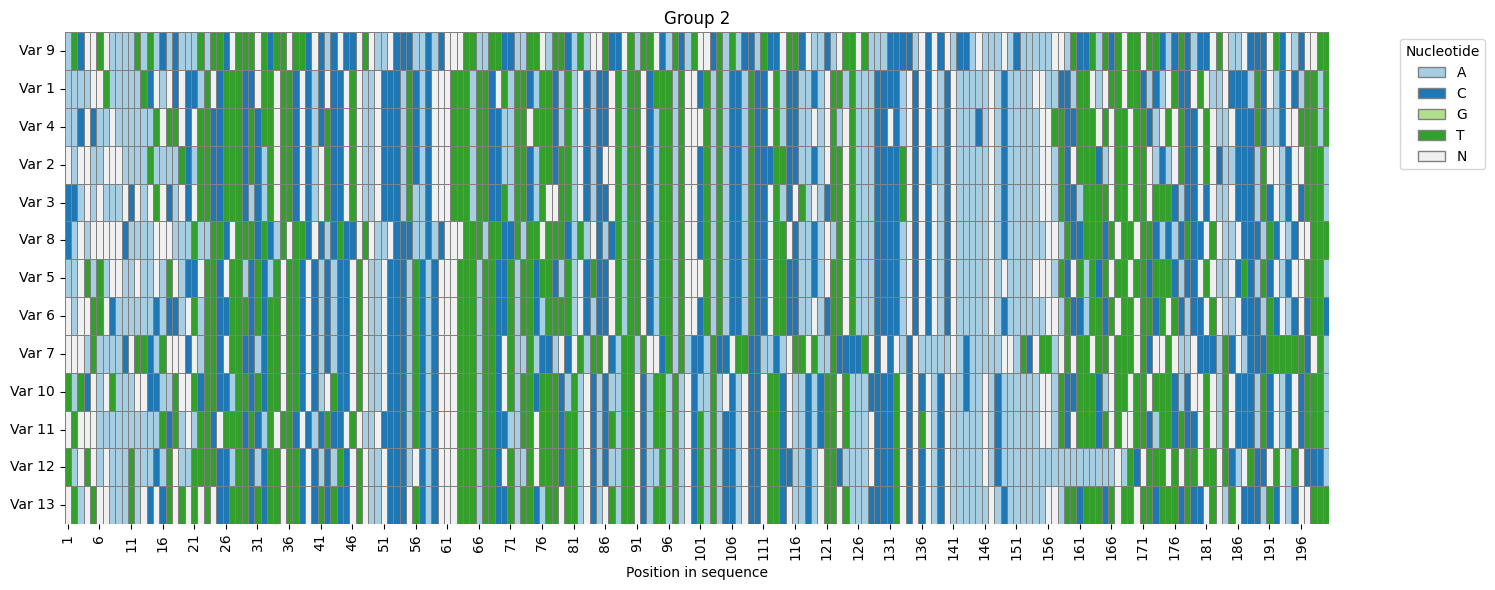

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram
from matplotlib.patches import Patch

# Take the first 15 sequences
seqs = filtered_variants_reordered["ref_seq"].iloc[2630:2643].tolist()

# Convert sequences to numeric (A=0, C=1, G=2, T=3, N=4)
nt_to_int = {'A':0, 'C':1, 'G':2, 'T':3, 'N':4}
seq_array = np.array([[nt_to_int.get(nt, 4) for nt in seq] for seq in seqs])

# Compute pairwise Hamming distance
dist_matrix = pdist(seq_array, metric='hamming')

# Hierarchical clustering
linkage_matrix = linkage(dist_matrix, method='average')

# Plot dendrogram to get order
plt.figure(figsize=(12, 8))
dendro = dendrogram(linkage_matrix, labels=[f"Var {i+1}" for i in range(len(seqs))], orientation='left')

# Reorder sequences
seq_array_ordered = seq_array[dendro['leaves'], :]

# Define nicer color palette for nucleotides
nt_colors = ["#A6CEE3", "#1F78B4", "#B2DF8A", "#33A02C", "#F0F0F0"]  # A, C, G, T, N
cmap = sns.color_palette(nt_colors)

# Plot heatmap
plt.figure(figsize=(15, 6))
sns.heatmap(seq_array_ordered, cmap=cmap, cbar=False, linewidths=0.5, linecolor='grey')
plt.yticks(np.arange(0.5, len(seqs)+0.5), [f"Var {i+1}" for i in dendro['leaves']], rotation=0)
plt.xticks(np.arange(0.5, seq_array.shape[1]+0.5, 5), np.arange(1, seq_array.shape[1]+1, 5))
plt.xlabel("Position in sequence")
plt.title("Group 2")

# Add legend for nucleotides
legend_elements = [Patch(facecolor=nt_colors[i], edgecolor='grey', label=nt) for i, nt in enumerate(['A', 'C', 'G', 'T', 'N'])]
plt.legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left', title="Nucleotide")

plt.tight_layout()
plt.show()


In [15]:
seqs

['AAAATTGAAAAAGCTATCTCCAGTCGGGCCTGGTGGCTCACTCCTGTAATCCCAGCACTTTGGGAGGCTGAGGCAGGCAGATCACCTGAGGTCGGGAGTTCGAGACCAGCCTGACCAACATGGAGAAACCCCATCTCTACTAAAAATACAAAATTAACCAGGTATGGTGGCACATGCCTGTAATCCCAGCTACTCAGGAG',
 'TATTAATTTAAAAGAAAAGCAGGCCGGGCGCAGTGGCTCATGCCTGTAATCCCAGCACTTTGGGAGGCCAAGGCAGGCGGATCACTTGAGGTCAGGAGTTCGAGACCAGCCCGGCCAACATGGTGAAACCCCGTCTCAACTAAAAATACAAAAATTAGCTGGGCATGGTGGTACATGCCTGTCAACCCAGTTACTTGGGA',
 'CCATATAAATCTATGTCATCTGGCCGGGCACAGTGGCTCATGCCTGTAATCCCAGAACTTTGGGAGGCCGAGGCAGTTGGATCACCTGAGGTCAGGAGTTCGAGACCAGCCTGACTGATACGGTGAAACCCCGTCTCTACTAAAAATACAAAAATTAGCCAGGGGTGGTGGTGGGCACCTCTAATCCCAGCTACTCGGGA',
 'AACTCAATAAAAAAGTGGTCTGGCCGGGCGCGGTGGCTCACGCCTGTAATCCCAGCACTTTGGGAGGCCAAGGTGGGCAGATCACCTGAGGTCAGGAGTTTGAGACCAGCCTGACCAATATGATGAAACCTCATCTCTACTAAACATACAAAAATTGGCCGGGTGTGGTGGCATGTGCCTGTAATCCCGCAACTTGGGAG',
 'AATGAGATTAATAATAGTACCTGGCTGGACGCAGTGGCTCACACCTGTAATCCCAGCACTTTGGGAGGCCGAGGCGGCAGATCGCCTGAGGTCAGGAGTTTGAGACCAGCCTGGCCAACATGGTGAAACCCCATCTCTACTAAAAATATAAAATTTAGCTGAGCGTGGTGGCGGGCAC

### We now introduce the reverse complements to produce the high vs low plot

In [16]:
import ast
import gzip
import numpy as np
import pandas as pd
import seaborn as sns
from Bio import SeqIO
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

delta_df = pd.read_csv("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_OT_1_rc.csv")

# predictions = pd.read_csv(
#     "/scratch/st-cdeboer-1/sambina/position_mpra/outputs/2-opentargets_model_variant_effect/gosai/k562_gosai_revcomp.csv.gz",
#     compression="gzip"
# )

# predictions["offset_0"] = predictions["offset_0"].apply(ast.literal_eval)


# predictions["variant_effect"] = predictions["offset_0"].apply(lambda val: val[0])

# filtered_variants = predictions[
#     (predictions["variant_effect"] > 0.5) | (predictions["variant_effect"] < -0.5)
# ]

print(filtered_variants.shape)
print(delta_df.shape)

(2956, 6)
(2956, 13)


In [17]:
import ast 

delta_df["ism_rc"] = delta_df["ism_rc"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=float)
)

In [18]:
# Compute average ISM per sequence
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
import ast

# --- Average numeric entries from dicts ---
def avg_numeric_dicts(dict_list):
    vals = []
    for d in dict_list:
        nums = [v for k, v in d.items() if isinstance(v, (int, float))]
        vals.append(np.mean(nums) if nums else np.nan)
    return np.array(vals)

# Apply across all rows
delta_df["ism_predictions_ref_rc"] = delta_df["ism_predictions_ref_rc"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=dict)
)
# Apply across all rows
delta_df["ism_predictions_alt_rc"] = delta_df["ism_predictions_alt_rc"].apply(
    lambda x: np.array(ast.literal_eval(x), dtype=dict)
)

ism_alt_avg = delta_df["ism_predictions_alt_rc"].apply(avg_numeric_dicts)
ism_ref_avg = delta_df["ism_predictions_ref_rc"].apply(avg_numeric_dicts)

# Variant effect
variant_effect = filtered_variants["variant_effect"].values

# Initialize lists
high_rows = []
low_rows = []

for i, effect in enumerate(variant_effect):
    if effect > 0:
        # high effect → take ref ISM
        high_rows.append(ism_ref_avg.iloc[i])
        # low effect → take alt ISM
        low_rows.append(ism_alt_avg.iloc[i])
    else:
        # effect < 0 → flip
        high_rows.append(ism_alt_avg.iloc[i])
        low_rows.append(ism_ref_avg.iloc[i])

# Convert to arrays for heatmaps
high_array = np.vstack(high_rows)
low_array  = np.vstack(low_rows)


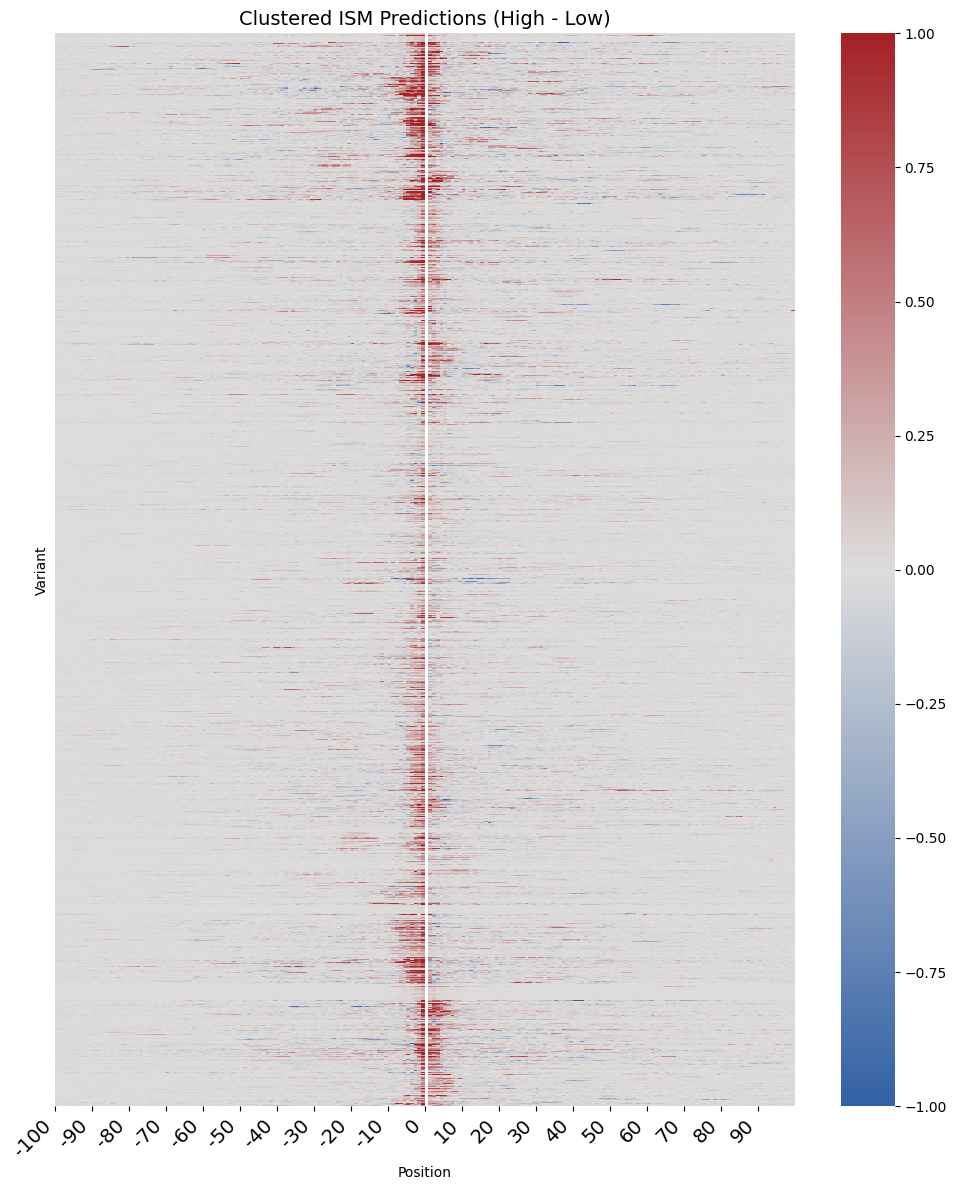

In [19]:
diff_array = high_array - low_array

from scipy.cluster.hierarchy import linkage, leaves_list

# Reorder diff_array and row labels according to clustering
heatmap_array = diff_array[row_order]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1


coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (High - Low)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
tick_positions = np.arange(0, 200, 10)
tick_labels    = np.arange(-100, 100, 10)

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=14)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_rc.png", dpi=1200)
plt.show()


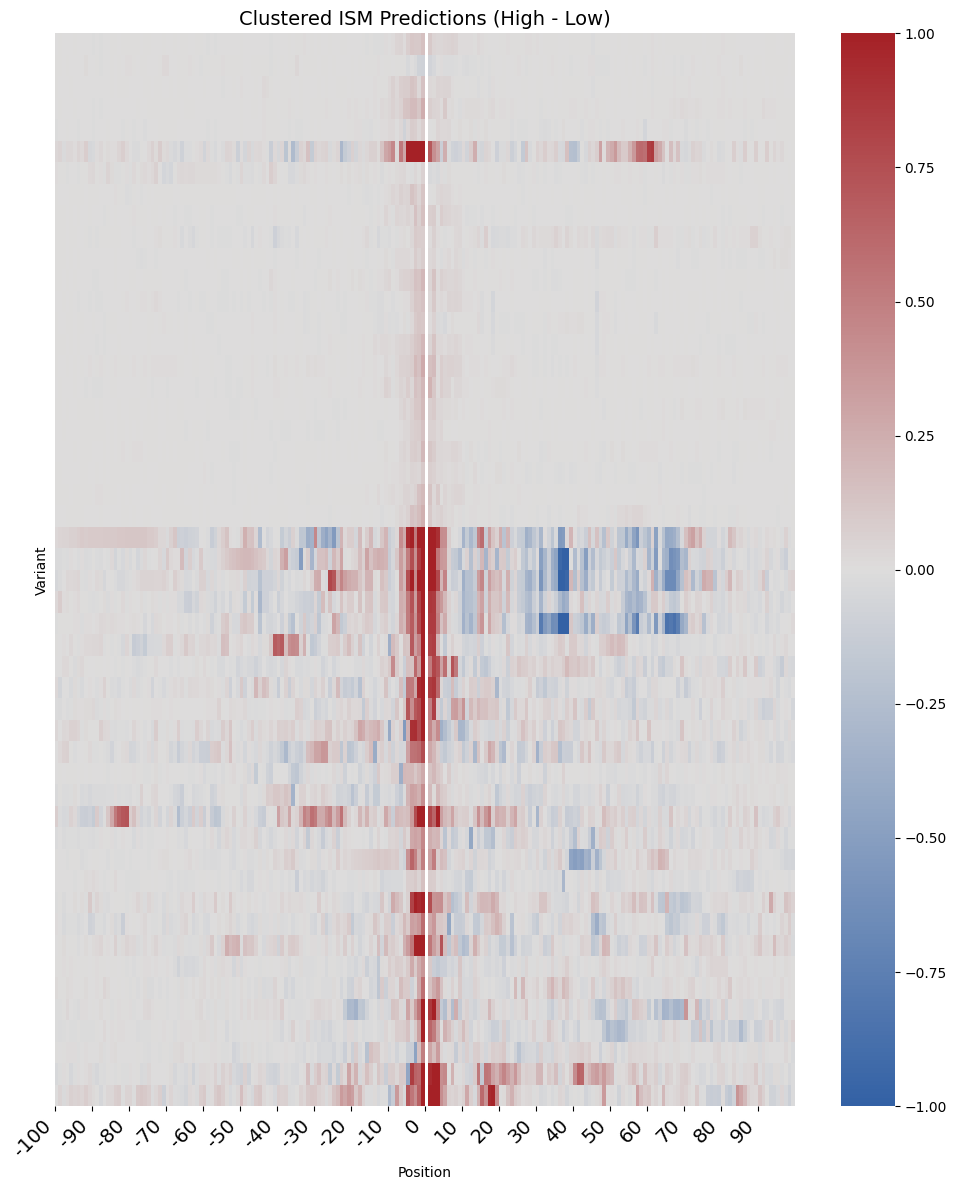

In [20]:
### Only plotting 2630 to 2643 for revcomp and forward

# diff_array = high_array - low_array
# diff_array = diff_array[0:50]
from scipy.cluster.hierarchy import linkage, leaves_list

# Reorder diff_array and row labels according to clustering
heatmap_array = heatmap_array[0:50]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1


coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (High - Low)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
tick_positions = np.arange(0, 200, 10)
tick_labels    = np.arange(-100, 100, 10)

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=14)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_rc_group1.png", dpi=1200)
plt.show()



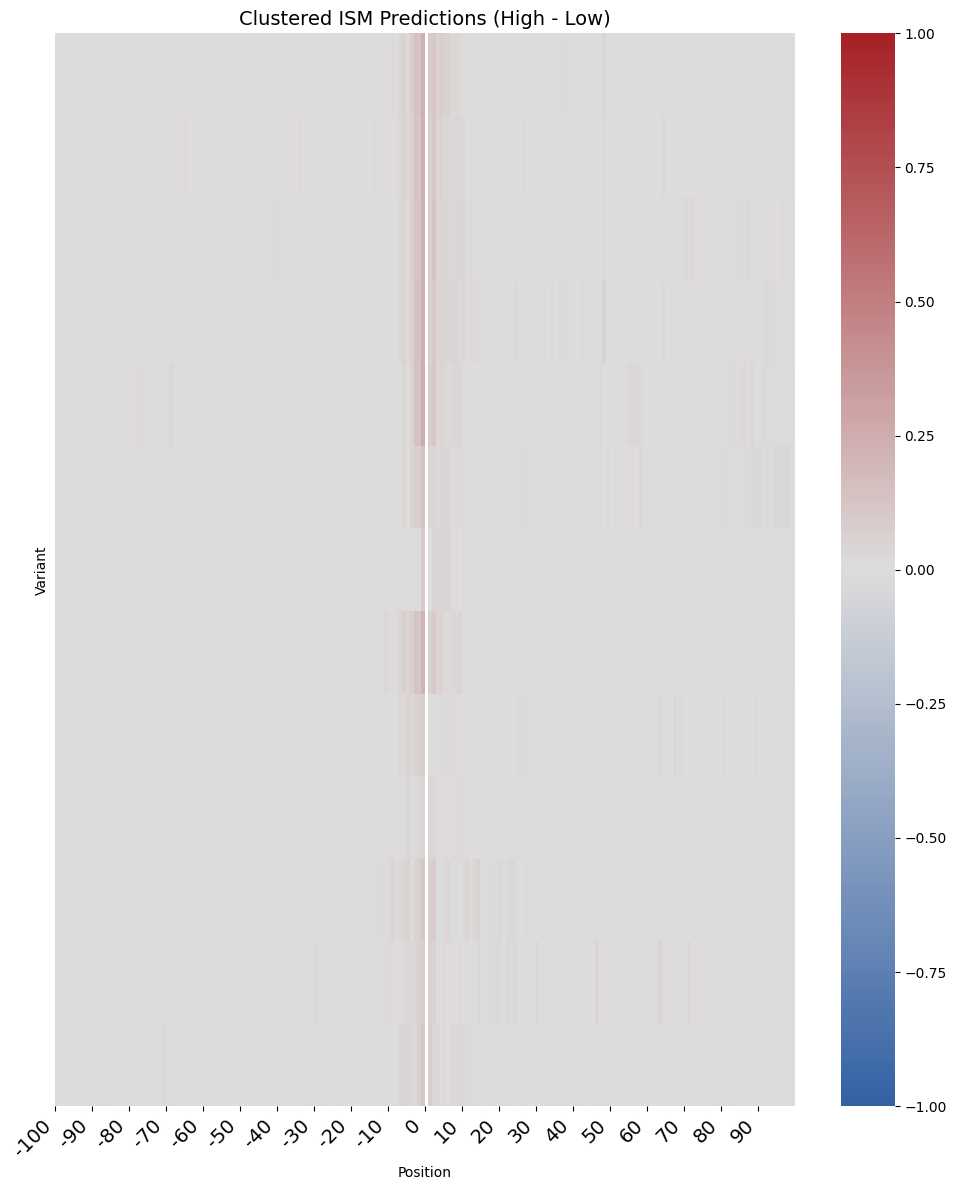

In [21]:
### Only plotting 2630 to 2643 for revcomp and forward

from scipy.cluster.hierarchy import linkage, leaves_list
diff_array = high_array - low_array

# Reorder diff_array and row labels according to clustering
heatmap_array = diff_array[row_order]
# Reorder diff_array and row labels according to clustering
heatmap_array = heatmap_array[2630:2643]

# --- Mask the 99th position (0-based = 100th) ---
mask = np.zeros_like(heatmap_array, dtype=bool)
if heatmap_array.shape[1] > 99:
    mask[:, 100] = True

# --- Shared color scale ---
heatmap_array = np.clip(heatmap_array, -1, 1)
vmin, vmax = -1, 1


coolwarm = plt.cm.coolwarm
mid_grey = coolwarm(0.5)
white_pos = abs(vmin) / (vmax - vmin)  # normalize position of white center (usually 0)
colors = [
    (0, "#3361A5"),        # dark blue at min
    (white_pos, mid_grey), # white at 0
    (1.0, "#A52126")        # dark red at max
]
custom_cmap = LinearSegmentedColormap.from_list("blue_white_red", colors)

# --- Plot ---
plt.figure(figsize=(10, 12))
sns.heatmap(
    heatmap_array,
    cmap=custom_cmap,
    center=0,
    vmin=vmin,
    vmax=vmax,
    xticklabels=10,
    yticklabels="",
    mask=mask,
    cbar=True
)

plt.title("Clustered ISM Predictions (High - Low)", fontsize=14)
plt.xlabel("Position")
plt.ylabel("Variant")
tick_positions = np.arange(0, 200, 10)
tick_labels    = np.arange(-100, 100, 10)

plt.xticks(tick_positions, tick_labels, rotation=45, ha="right", fontsize=14)
plt.tight_layout()
plt.savefig("/scratch/st-cdeboer-1/sambina/position_mpra/outputs/6-ism_variant_effects/delta_ism_rc_group2.png", dpi=1200)
plt.show()



### Plotting RC separately